# 04. Модель прогноза и ошибка

Ноутбук обучает модель прогноза `net_sales_qty`, использует последние 28 дней как holdout, сравнивает результат с лучшим baseline и сохраняет артефакты в `results/`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.config import PROCESSED_DATA_DIR, RESULTS_DIR
from src.features import build_feature_matrix
from src.modeling import (
    compare_with_best_baseline,
    evaluate_model,
    prepare_train_test,
    predict_non_negative,
    save_feature_importance,
    save_model_metrics,
    save_predictions,
    train_model,
)

## Загрузка признаков

In [2]:
features_path = PROCESSED_DATA_DIR / 'features_lags_rolling.csv'
if features_path.exists():
    features = pd.read_csv(features_path, parse_dates=['sales_date'])
else:
    mart_daily_sales = pd.read_csv(PROCESSED_DATA_DIR / 'mart_daily_sales.csv', parse_dates=['sales_date'])
    features = build_feature_matrix(mart_daily_sales)
    features.to_csv(features_path, index=False)

features.head()

C:\Users\Ahmed The Best\AppData\Local\Temp\ipykernel_32460\1275947189.py:3: DtypeWarning: Columns (0: stock_code) have mixed types. Specify dtype option on import or set low_memory=False.
  features = pd.read_csv(features_path, parse_dates=['sales_date'])


,sales_date,stock_code,description,market_id,sales_qty,avg_unit_price,revenue,invoices_cnt,customers_cnt,returns_qty,...,customers_cnt_lag_7,rolling_mean_7,rolling_mean_28,rolling_std_28,rolling_median_28,avg_unit_price_lag_7,price_change_abs,price_change_pct,days_since_last_sale,zero_sales_streak
0,2010-03-04,10002,INFLATABLE POLITICAL GLOBE,Australia,12,0.85,10.2,1,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2010-10-26,10002,INFLATABLE POLITICAL GLOBE,Australia,24,0.85,20.4,1,1,0,...,NaN,12.0,12.0,NaN,12.0,NaN,NaN,NaN,236.0,0
2,2010-01-11,10002,INFLATABLE POLITICAL GLOBE,Denmark,48,0.85,40.8,1,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,2010-04-22,10002,INFLATABLE POLITICAL GLOBE,Denmark,200,0.72,144.0,1,1,0,...,NaN,48.0,48.0,NaN,48.0,NaN,NaN,NaN,101.0,0
4,2010-11-02,10002,INFLATABLE POLITICAL GLOBE,Denmark,24,0.85,20.4,1,1,0,...,NaN,124.0,124.0,107.480231,124.0,NaN,NaN,NaN,194.0,0


## Разделение на train и holdout

Holdout — последние 28 календарных дней. Такой порядок нужен, чтобы проверка имитировала прогноз будущего периода.

In [3]:
train, holdout, feature_columns = prepare_train_test(features, holdout_days=28)
train[['sales_date', 'stock_code', 'market_id', 'net_sales_qty']].tail(), holdout[['sales_date', 'stock_code', 'market_id', 'net_sales_qty']].head()

(       sales_date stock_code       market_id  net_sales_qty
 552450 2011-11-07      22488  United Kingdom              8
 552451 2011-11-07      22476  United Kingdom              1
 552452 2011-11-07      22476        Portugal              3
 552453 2011-11-07      22475  United Kingdom              2
 552454 2011-11-07      22530  United Kingdom             24,
        sales_date stock_code       market_id  net_sales_qty
 552455 2011-11-08      23256  United Kingdom             11
 552456 2011-11-08      23254  United Kingdom             11
 552457 2011-11-08      23254          France              4
 552458 2011-11-08      23263  United Kingdom             48
 552459 2011-11-08      23264  United Kingdom             12)

## Обучение и прогноз

In [4]:
model = train_model(train, feature_columns)
forecast = predict_non_negative(model, holdout, feature_columns)
model_metrics = evaluate_model(holdout['net_sales_qty'], forecast)
model_metrics

{'wmape': 0.7995855552959904,
 'mae': 15.58851743586571,
 'rmse': 77.11896707084692,
 'bias': 0.10516821039012454,
 'service_level_proxy': 0.728521312452709,
 'stockout_risk_rate': 0.27147868754729093}

## Сравнение с baseline

In [5]:
baseline_path = RESULTS_DIR / 'baseline_metrics.csv'
baseline_metrics = pd.read_csv(baseline_path) if baseline_path.exists() else None
comparison = compare_with_best_baseline(model_metrics, baseline_metrics)
comparison

,source,metric,value
0,model,wmape,0.799586
1,median_by_weekday,wmape,0.857446


## Сохранение результатов

In [6]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
save_model_metrics(model_metrics, RESULTS_DIR / 'model_metrics.csv')
save_predictions(holdout, forecast, RESULTS_DIR / 'forecast_vs_actual_sample.csv')
feature_importance_path = save_feature_importance(model, feature_columns, RESULTS_DIR / 'feature_importance.csv')
comparison.to_csv(RESULTS_DIR / 'model_vs_baseline.csv', index=False)
feature_importance_path

WindowsPath('C:/считай что диск D/Pet_project/retail-demand-inventory-analytics/results/feature_importance.csv')

## Важность признаков

In [7]:
if feature_importance_path is not None:
    feature_importance = pd.read_csv(feature_importance_path)
    display(feature_importance.head(20))
else:
    feature_importance = pd.DataFrame(columns=['feature', 'importance'])
    print('Текущая модель не предоставляет важность признаков.')

,feature,importance
0,avg_unit_price,1000
1,rolling_median_28,674
2,price_change_pct,451
3,month,428
4,rolling_mean_28,418
5,avg_unit_price_lag_7,401
6,rolling_mean_7,394
7,price_change_abs,374
8,weekday,299
9,rolling_std_28,278


## График факт против прогноза

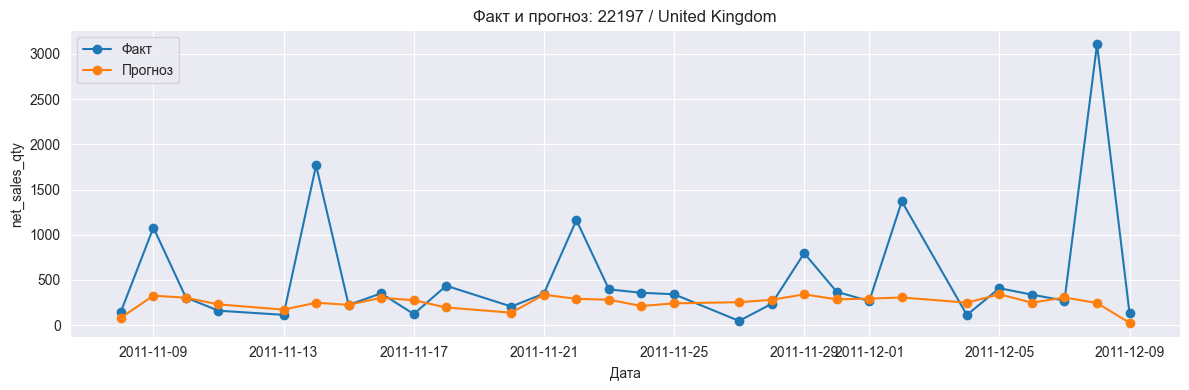

In [8]:
plot_frame = holdout[['sales_date', 'stock_code', 'market_id', 'net_sales_qty']].copy()
plot_frame['forecast_net_sales_qty'] = forecast.to_numpy()

sample_key = plot_frame.groupby(['stock_code', 'market_id'])['net_sales_qty'].sum().sort_values(ascending=False).index[0]
sample = plot_frame[(plot_frame['stock_code'] == sample_key[0]) & (plot_frame['market_id'] == sample_key[1])]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sample['sales_date'], sample['net_sales_qty'], marker='o', label='Факт')
ax.plot(sample['sales_date'], sample['forecast_net_sales_qty'], marker='o', label='Прогноз')
ax.set_title(f'Факт и прогноз: {sample_key[0]} / {sample_key[1]}')
ax.set_xlabel('Дата')
ax.set_ylabel('net_sales_qty')
ax.legend()
plt.tight_layout()

## Выводы

- WMAPE модели: `[A]`.
- MAE модели: `[B]`.
- RMSE модели: `[C]`.
- Forecast bias: `[D]`.
- Сравнение с лучшим baseline по WMAPE: `[E]`.
- Если bias положительный, прогноз завышает спрос; если отрицательный, занижает.